# Kaplan‑Meier Analysis of Lung Cancer Survival
**Author:** Oluwatobi Elegbede  

**Dataset:** `lifelines.datasets.load_lung()` – 228 patients with lung cancer.

**Objective:** Estimate overall survival and compare by sex using KM curves and log‑rank test.

In [36]:
# Install lifelines
!pip install -q lifelines

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.datasets import load_lung
from lifelines.utils import median_survival_times

In [37]:
import lifelines
print("lifelines version:", lifelines.__version__)

lifelines version: 0.30.3


In [38]:
# Load data
df = load_lung()

# See first few rows
print(df.shape)
df.head()


(228, 10)


,inst,time,status,age,sex,ph.ecog,ph.karno,pat.karno,meal.cal,wt.loss
0,3.0,306,1,74,1,1.0,90.0,100.0,1175.0,NaN
1,3.0,455,1,68,1,0.0,90.0,90.0,1225.0,15.0
2,3.0,1010,0,56,1,0.0,90.0,90.0,NaN,15.0
3,5.0,210,1,57,1,1.0,90.0,60.0,1150.0,11.0
4,1.0,883,1,60,1,0.0,100.0,90.0,NaN,0.0


## 1. Data Overview
The dataset contains:
- `time`: Survival time in days
- `status`: 1 = death, 0 = censored
- `sex`: 1 = male, 2 = female

In [39]:
# Create KaplanMeierFitter object
kmf = KaplanMeierFitter()

# Fit the model
kmf.fit(durations=df['time'], event_observed=df['status'])

# Print median survival time
median_survival = kmf.median_survival_time_
print(f"Median survival time: {median_survival:.1f} days")

Median survival time: 310.0 days


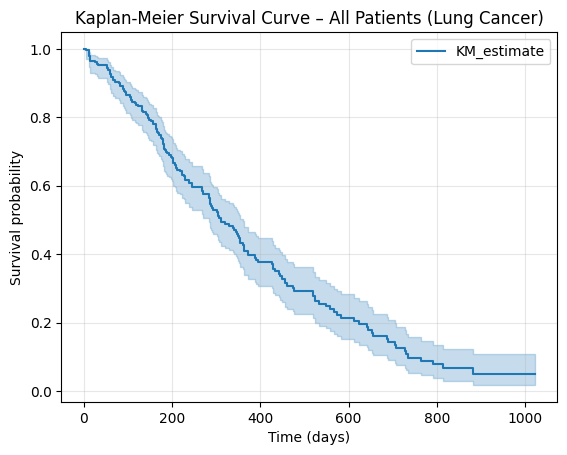

In [40]:
# Plot
kmf.plot_survival_function(ci_show = True)
plt.title('Kaplan-Meier Survival Curve – All Patients (Lung Cancer)')
plt.xlabel('Time (days)')
plt.ylabel('Survival probability')
plt.grid(alpha=0.3)
plt.show()

## 2. Overall Survival
Median survival: **310 days**. The curve shows gradual decline with a plateau after ~900 days.

In [41]:
# Separate by sex
males = df['sex'] == 1
females = df['sex'] == 2

# Fit separately
kmf_male = KaplanMeierFitter()
kmf_female = KaplanMeierFitter()

kmf_male.fit(df[males]['time'], event_observed=df[males]['status'])
kmf_female.fit(df[females]['time'], event_observed=df[females]['status'])

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 90 total observations, 37 right-censored observations>

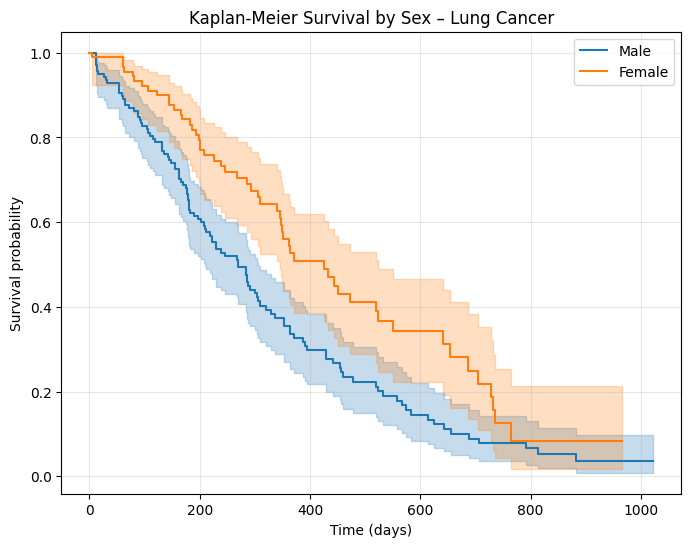

In [42]:
plt.figure(figsize=(8,6))

kmf_male.plot_survival_function(label='Male', ci_show = True)
kmf_female.plot_survival_function(label='Female', ci_show = True)

plt.title('Kaplan-Meier Survival by Sex – Lung Cancer')
plt.xlabel('Time (days)')
plt.ylabel('Survival probability')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [43]:
from lifelines.statistics import logrank_test

results = logrank_test(
    durations_A=df[males]['time'],
    event_observed_A=df[males]['status'],
    durations_B=df[females]['time'],
    event_observed_B=df[females]['status']
)

print(results)

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
          10.33 <0.005      9.57


## 3. Survival by Sex
Females have consistently higher survival probability. The log‑rank test is highly significant (p < 0.005), indicating a real difference.

In [44]:
# Select time points
times = [0, 100, 200, 300, 400, 500, 600, 700, 900]

# Function to get number at risk at time t
def n_at_risk(df, time, status, t):
    return ((df[time] >= t) & ((df[status] == 0) | (df[time] > t))).sum()

print("Time (days) | Number at risk (all patients)")
print("------------------------------------------")
for t in times:
    n = n_at_risk(df, 'time', 'status', t)
    print(f"{t:11} | {n:18}")

Time (days) | Number at risk (all patients)
------------------------------------------
          0 |                228
        100 |                196
        200 |                144
        300 |                 92
        400 |                 57
        500 |                 41
        600 |                 24
        700 |                 16
        900 |                  3


## 4. Limitations
Univariate analysis only; no adjustment for age, performance status, or treatment.

- Next step: Multivariable Cox regression.